# 03. Baseline Fail Prediction
Train/Test 누수를 방지하는 Pipeline으로 baseline 모델을 비교합니다. 모델 선택과 threshold 조정은 Train 데이터 내부에서만 수행하며, 최종 Test 세트는 마지막 평가에 한 번만 사용합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.secom_analysis import load_secom, data_quality_reports
from src.modeling import (
    build_baseline_models,
    classification_metrics,
    cross_validated_model_comparison,
    default_threshold_test_comparison,
    out_of_fold_probabilities,
    select_recall_constrained_threshold,
    stratified_holdout,
    threshold_table,
)

REPORT_DIR = PROJECT_ROOT / 'reports'
REPORT_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\user\Desktop\취준\semiconductor_yield_quality_analysis


## 1. Data split and leakage control
결측치 대체와 스케일링은 각 Pipeline 내부에서 학습합니다. 전체 데이터의 라벨 비율을 유지하는 stratified holdout을 만들고, Test 데이터는 모델 및 threshold 선택에 사용하지 않습니다.

In [2]:
X, labels = load_secom(PROJECT_ROOT / 'data/raw')
_, _, _, _, kept_features = data_quality_reports(X, labels['is_fail'])
X_model = X[kept_features]
y = labels['is_fail']
X_train, X_test, y_train, y_test = stratified_holdout(X_model, y)

print('Model features:', X_model.shape[1])
print('Train:', X_train.shape, 'Fail:', int(y_train.sum()))
print('Test:', X_test.shape, 'Fail:', int(y_test.sum()))

Model features: 446
Train: (1253, 446) Fail: 83
Test: (314, 446) Fail: 21


## 2. Repeated cross-validation on Train
Dummy, class-weighted Logistic Regression, Random Forest, HistGradientBoosting을 Train 데이터의 5-fold × 3회 반복 교차검증으로 비교합니다. 모델 선택 기준은 PR-AUC입니다.

In [3]:
models = build_baseline_models()
cv_results = cross_validated_model_comparison(models, X_train, y_train)
cv_results.to_csv(REPORT_DIR / 'model_comparison.csv', index=False)
display(cv_results)

,model,pr_auc_mean,pr_auc_std,fail_recall_mean,fail_recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std
0,random_forest_balanced,0.198451,0.075094,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
1,hist_gradient_boosting_balanced,0.168039,0.051591,0.023775,0.037464,0.226667,0.367359,0.041361,0.062971,0.509323,0.018721
2,logistic_balanced,0.163114,0.058157,0.305392,0.115112,0.147939,0.054073,0.198181,0.071468,0.589733,0.059622
3,dummy_prior,0.066237,0.001891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000


In [4]:
test_default, fitted_models = default_threshold_test_comparison(
    models, X_train, y_train, X_test, y_test
)
test_default.to_csv(REPORT_DIR / 'test_model_comparison.csv', index=False)
display(test_default)

,model,threshold,fail_recall,precision,f1,pr_auc,balanced_accuracy,true_negative,false_positive,false_negative,true_positive
0,random_forest_balanced,0.5,0.000000,0.000000,0.000000,0.200315,0.500000,293,0,21,0
1,hist_gradient_boosting_balanced,0.5,0.000000,0.000000,0.000000,0.182106,0.496587,291,2,21,0
2,logistic_balanced,0.5,0.190476,0.095238,0.126984,0.117519,0.530392,255,38,17,4
3,dummy_prior,0.5,0.000000,0.000000,0.000000,0.066879,0.500000,293,0,21,0


## 3. Train-only threshold selection
Dummy 모델을 제외하고 Train 반복 교차검증 PR-AUC가 가장 높은 모델을 선택합니다. 해당 모델의 out-of-fold 확률에서 Fail Recall 80% 이상을 만족하면서 Precision이 가장 높은 threshold를 결정합니다.

In [5]:
selected_model_name = cv_results.loc[
    cv_results['model'].ne('dummy_prior')
, 'model'].iloc[0]
selected_model = models[selected_model_name]
oof_probabilities = out_of_fold_probabilities(selected_model, X_train, y_train)
threshold_results = threshold_table(y_train, oof_probabilities)
selected_threshold = select_recall_constrained_threshold(threshold_results, minimum_recall=0.80)
threshold_results['selected'] = threshold_results['threshold'].eq(selected_threshold)
threshold_results.to_csv(REPORT_DIR / 'threshold_comparison.csv', index=False)
print('Selected model:', selected_model_name)
print('Selected threshold:', selected_threshold)
display(threshold_results.loc[threshold_results['selected']])

Selected model: random_forest_balanced
Selected threshold: 0.06


,threshold,fail_recall,precision,f1,pr_auc,balanced_accuracy,true_negative,false_positive,false_negative,true_positive,selected
5,0.06,0.807229,0.094633,0.169406,0.187503,0.629683,529,641,16,67,True


## 4. Final untouched Test evaluation
선택한 모델을 전체 Train 데이터에 적합하고, 사전에 결정한 threshold로 Test 성능을 한 번 평가합니다.

In [6]:
selected_model.fit(X_train, y_train)
test_probabilities = selected_model.predict_proba(X_test)[:, 1]
final_metrics = pd.DataFrame([
    classification_metrics(
        y_test, test_probabilities, selected_threshold, model=selected_model_name
)
])
final_metrics.to_csv(REPORT_DIR / 'selected_model_test_metrics.csv', index=False)
display(final_metrics)

,model,threshold,fail_recall,precision,f1,pr_auc,balanced_accuracy,true_negative,false_positive,false_negative,true_positive
0,random_forest_balanced,0.06,0.857143,0.102857,0.183673,0.200315,0.660653,136,157,3,18


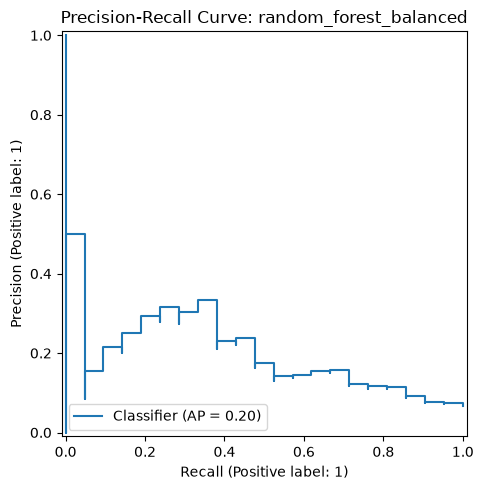

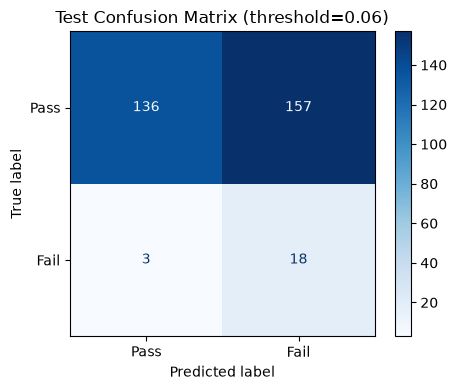

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=ax)
ax.set_title(f'Precision-Recall Curve: {selected_model_name}')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'precision_recall_curve.png', dpi=160)
plt.show()

test_predictions = (test_probabilities >= selected_threshold).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=['Pass', 'Fail'], cmap='Blues', ax=ax
)
ax.set_title(f'Test Confusion Matrix (threshold={selected_threshold:.2f})')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'confusion_matrix_selected_model.png', dpi=160)
plt.show()

## Interpretation
최종 운영점은 Fail 미검출(False Negative)을 줄이는 대신 False Alarm을 얼마나 허용할지 보여줍니다. 단일 holdout 결과는 표본 수가 적어 변동성이 있으므로 반복 교차검증 평균과 표준편차를 함께 보고해야 합니다. 향후에는 시간순 분할 안정성, permutation importance, 상위 feature 기반 SPC 후보를 추가 검증합니다.